In [1]:
!pip install category_encoders shap yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import shap
import category_encoders as ce

from scipy import stats
from scipy.stats import skew, boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from yellowbrick.regressor import ResidualsPlot, PredictionError
from category_encoders import TargetEncoder
from ipywidgets import interact

warnings.filterwarnings("ignore")

In [3]:
# Forma 2)

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1jpGoMg5UvzASd3uxbZFeWhByOY_eWIKo'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)
df
#https://drive.google.com/file/d/1jpGoMg5UvzASd3uxbZFeWhByOY_eWIKo/view?usp=sharing

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
Blast Furnace Slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
Fly Ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
Coarse Aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
Fine Aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
Strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


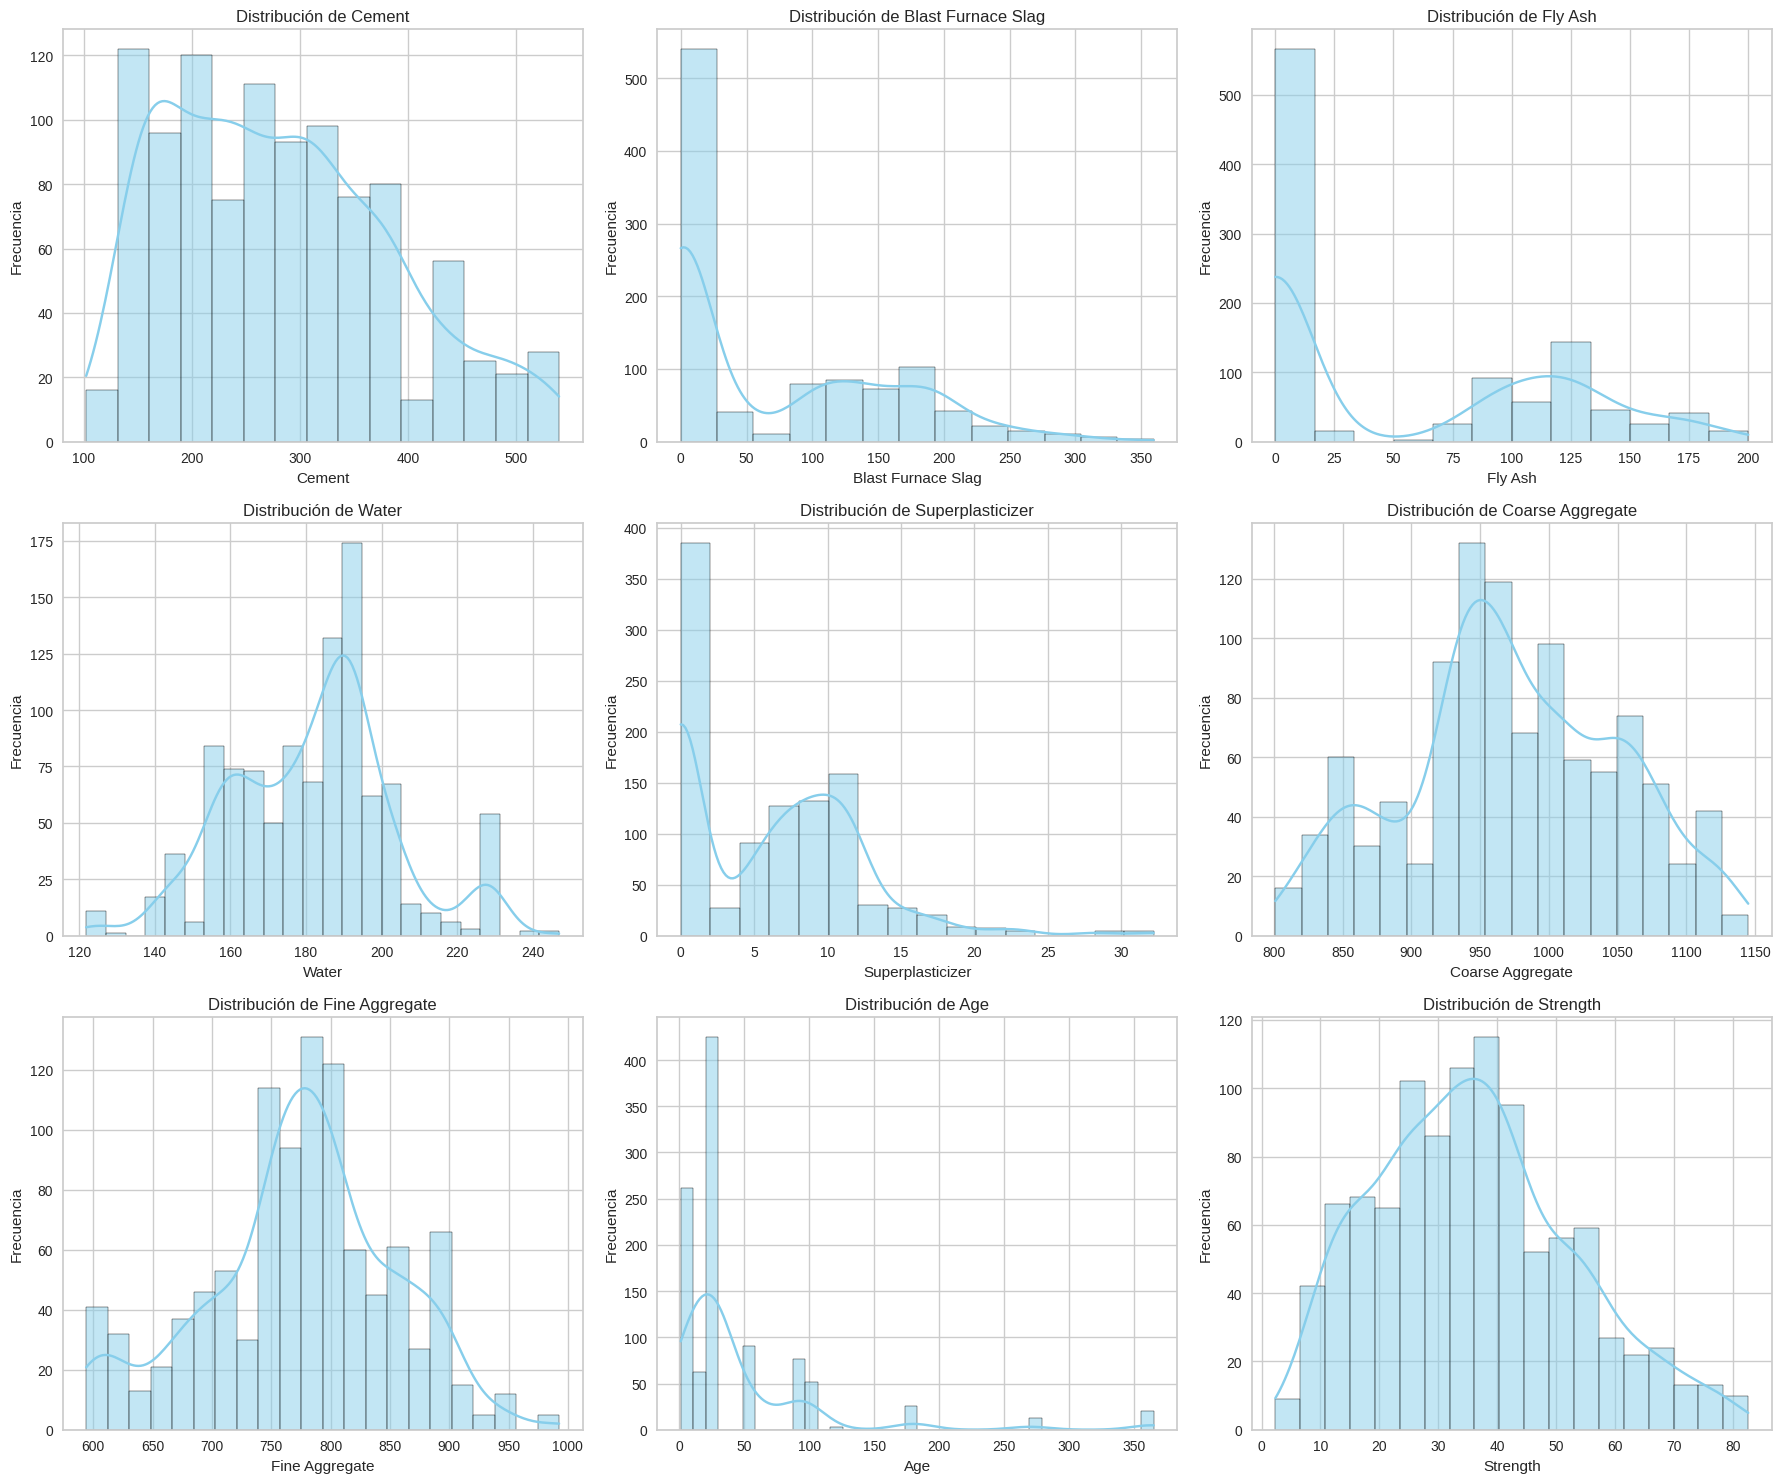

In [6]:
cols = df.columns
n_cols = 3
n_rows = (len(cols) - 1) // n_cols + 1

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

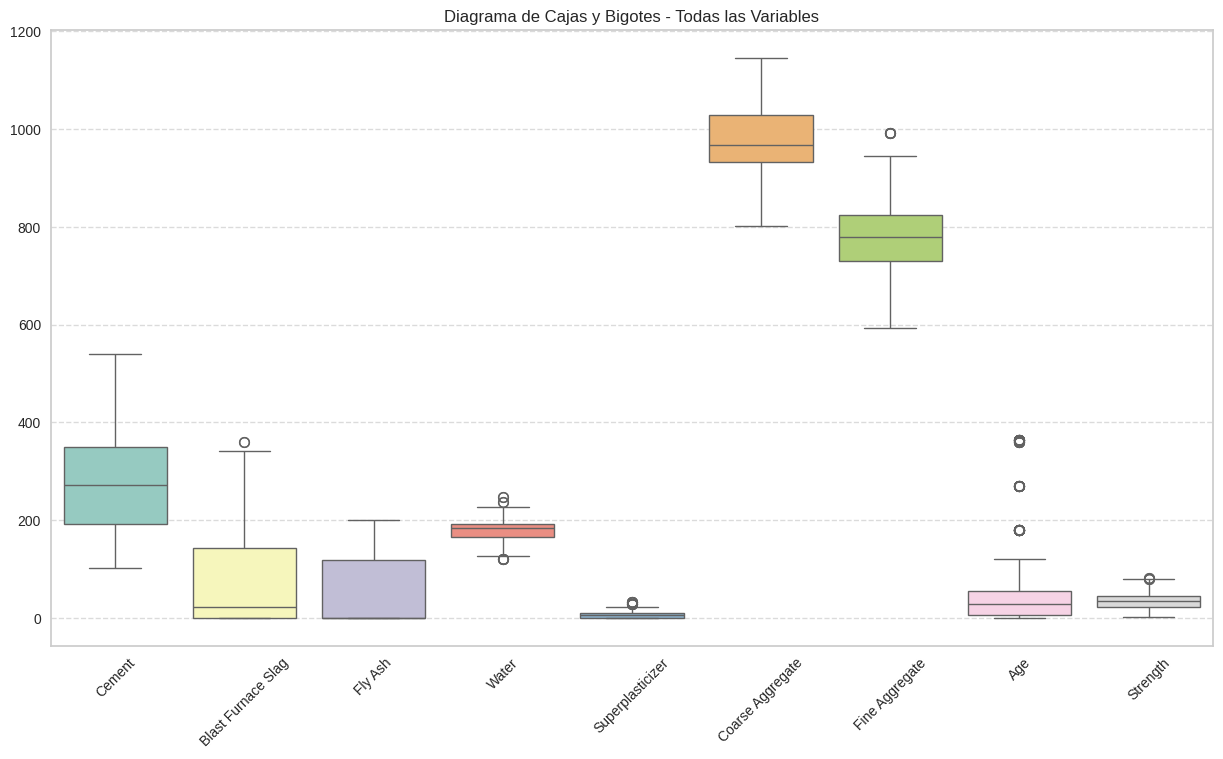

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Asegurar carga de datos si el kernel se reinició
file_id = '1jpGoMg5UvzASd3uxbZFeWhByOY_eWIKo'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

# Generar el gráfico de cajas y bigotes
plt.figure(figsize=(15, 8))
sns.boxplot(data=df, palette='Set3')
plt.title('Diagrama de Cajas y Bigotes - Todas las Variables')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

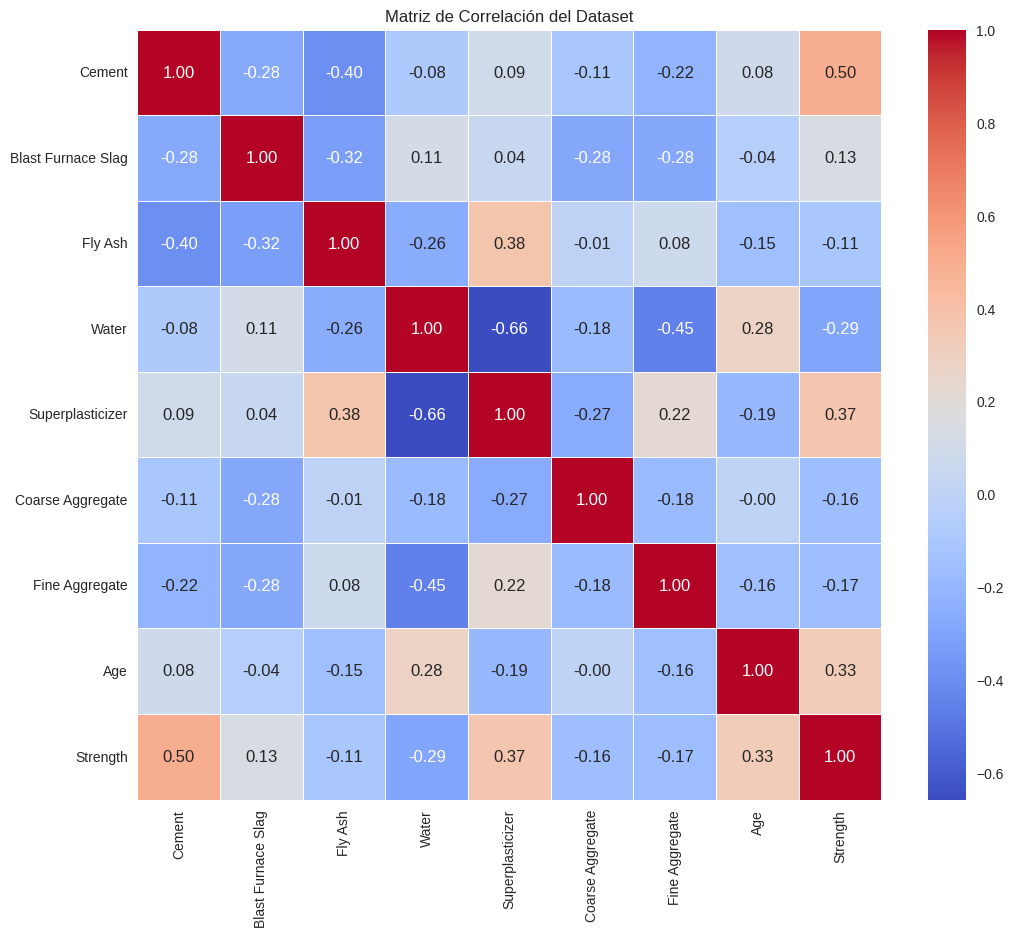

In [8]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación del Dataset')
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

# Identifying features and target
target = 'Strength'
features = [col for col in df.columns if col != target]

# Initializing the scaler
scaler = StandardScaler()

# Creating a copy of the dataframe to store scaled values
df_scaled = df.copy()

# Fitting and transforming the features
df_scaled[features] = scaler.fit_transform(df[features])

print('Dataset scaled successfully.')
display(df_scaled.head())

Dataset scaled successfully.


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733,79.99
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733,61.89
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066,40.27
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677,41.05
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487,44.30


### Escalado de Datos

Se ha aplicado **StandardScaler** a todas las variables excepto a `Strength`.

**¿Por qué escalar?**
Modelos como la Regresión Lineal (con regularización), KNN o Redes Neuronales son sensibles a la escala de las variables. Al estandarizar, nos aseguramos de que variables con rangos grandes (como `Cement` o `Coarse Aggregate`) no dominen injustamente sobre variables con rangos pequeños (como `Superplasticizer`).

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

# Define target and features
X = df_scaled.drop(columns=['Strength'])
y = df_scaled['Strength']

# Define split ratios to test
splits = [0.30, 0.25, 0.20]

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Elastic Net': ElasticNet(),
    'Polynomial (Deg 2)': Pipeline([('poly', PolynomialFeatures(degree=2)), ('linear', LinearRegression())]),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

results_list = []

# Run experiments
for test_size in splits:
    train_size = int((1 - test_size) * 100)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        r2 = r2_score(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))

        results_list.append({
            'Split (Train/Test)': f'{train_size}/{int(test_size*100)}',
            'Algorithm': name,
            'R2 Score': r2,
            'RMSE': rmse
        })

# Create summary table
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by=['R2 Score'], ascending=False)

print("Summary of Model Experiments:")
display(results_df)

Summary of Model Experiments:


,Split (Train/Test),Algorithm,R2 Score,RMSE
7,70/30,Gradient Boosting,0.891101,5.428198
6,70/30,Random Forest,0.889329,5.472176
17,75/25,Gradient Boosting,0.889090,5.481098
16,75/25,Random Forest,0.888398,5.498158
26,80/20,Random Forest,0.883799,5.471945
27,80/20,Gradient Boosting,0.882889,5.493350
25,80/20,Decision Tree,0.834750,6.525414
5,70/30,Decision Tree,0.825222,6.876804
14,75/25,Polynomial (Deg 2),0.784528,7.639705
24,80/20,Polynomial (Deg 2),0.784294,7.455364


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
Blast Furnace Slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
Fly Ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
Coarse Aggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
Fine Aggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
Strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


In [12]:
results_list = []

# Run experiments including MAE and MSE
for test_size in splits:
    train_size = int((1 - test_size) * 100)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        r2 = r2_score(y_test, predictions)
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        mse = mean_squared_error(y_test, predictions)

        results_list.append({
            'Split (Train/Test)': f'{train_size}/{int(test_size*100)}',
            'Algorithm': name,
            'R2 Score': r2,
            'RMSE': rmse,
            'MAE': mae,
            'MSE': mse
        })

# Create updated summary table
results_df_extended = pd.DataFrame(results_list)
results_df_extended = results_df_extended.sort_values(by=['R2 Score'], ascending=False)

print("Summary of Model Experiments (Extended Metrics):")
display(results_df_extended)

Summary of Model Experiments (Extended Metrics):


,Split (Train/Test),Algorithm,R2 Score,RMSE,MAE,MSE
7,70/30,Gradient Boosting,0.891101,5.428198,4.033826,29.465330
6,70/30,Random Forest,0.889329,5.472176,3.755800,29.944713
17,75/25,Gradient Boosting,0.889090,5.481098,4.103061,30.042431
16,75/25,Random Forest,0.888398,5.498158,3.767855,30.229736
26,80/20,Random Forest,0.883799,5.471945,3.738485,29.942186
27,80/20,Gradient Boosting,0.882889,5.493350,4.135014,30.176898
25,80/20,Decision Tree,0.834750,6.525414,4.293786,42.581023
5,70/30,Decision Tree,0.825222,6.876804,4.460388,47.290434
14,75/25,Polynomial (Deg 2),0.784528,7.639705,6.062470,58.365093
24,80/20,Polynomial (Deg 2),0.784294,7.455364,5.969586,55.582458


In [13]:
from ipywidgets import interact, FloatSlider, IntSlider

# 1. Re-entrenamos el mejor modelo (Gradient Boosting) con el split que dió mejor resultado (70/30)
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.30, random_state=42)
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train_final, y_train_final)

# 2. Función para realizar la predicción interactiva
def predict_strength(Cement, Blast_Furnace_Slag, Fly_Ash, Water, Superplasticizer, Coarse_Aggregate, Fine_Aggregate, Age):
    # Crear un DataFrame con los valores de entrada (sin escalar)
    input_data = pd.DataFrame([[Cement, Blast_Furnace_Slag, Fly_Ash, Water, Superplasticizer, Coarse_Aggregate, Fine_Aggregate, Age]],
                              columns=features)

    # Aplicar el mismo escalador (scaler) definido anteriormente
    input_scaled = scaler.transform(input_data)

    # Realizar la predicción
    prediction = best_model.predict(input_scaled)

    print(f"\n--- Predicción de Resistencia del Concreto ---")
    print(f"La resistencia estimada es: {prediction[0]:.2f} MPa")

# 3. Crear los controles interactivos basados en los rangos del dataset original
print("Ajusta los parámetros para obtener la predicción de Strength:")
interact(predict_strength,
         Cement=FloatSlider(min=100, max=540, step=1, value=280),
         Blast_Furnace_Slag=FloatSlider(min=0, max=360, step=1, value=70),
         Fly_Ash=FloatSlider(min=0, max=200, step=1, value=50),
         Water=FloatSlider(min=120, max=250, step=1, value=180),
         Superplasticizer=FloatSlider(min=0, max=32, step=0.1, value=6),
         Coarse_Aggregate=FloatSlider(min=800, max=1150, step=1, value=970),
         Fine_Aggregate=FloatSlider(min=590, max=1000, step=1, value=770),
         Age=IntSlider(min=1, max=365, step=1, value=28)
);

Ajusta los parámetros para obtener la predicción de Strength:


interactive(children=(FloatSlider(value=280.0, description='Cement', max=540.0, min=100.0, step=1.0), FloatSli…